# Analisi de Sequera al Valles Occidental

## Objectiu

Analitzar si les sequeres estan augmentant en **frequencia**, **durada** o **severitat** al Valles Occidental (Sabadell, Vacarisses) durant els últims 30 anys.

## Metodologia

Utilitzem l'indeix **SPEI** (Standardized Precipitation Evapotranspiration Index) que combina:
- Precipitacio (pluja acumulada)
- Temperatura (via evapotranspiracio potencial)

Aixo és mes rellevant que el SPI perquè captura l'efecte de l'escalfament global sobre la sequera.

## Estacions

| Estació | Període | Anys |
|---------|---------|------|
| Sabadell Nord | 2008-2026 | 18 anys |
| Sabadell Centre | 2008-2026 | 18 anys |
| Vacarisses | 1996-2026 | 30 anys |

---
## 1. Carreguem les llibreries

In [2]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Afegim el directori de scripts al path
sys.path.insert(0, '../../scripts')
from drought_analysis import (
    load_station, aggregate_monthly, thornthwaite_pet,
    compute_drought_indices, detect_drought_events,
    drought_statistics, full_analysis
)
from statistical_tests import mann_kendall, sens_slope, pettitt_test, mk_analysis_series

# Configuracio de grafics
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11
plt.style.use('seaborn-v0_8-whitegrid')
print('Llibreries carregades correctament.')

Llibreries carregades correctament.


---
## 2. Explicació dels paràmetres

### 2.1 PET (Potential Evapotranspiration) - Mètode de Thornthwaite

La **evapotranspiració potencial** és la quantitat d'aigua que **evaporaria** una superfície si tingués aigua il·limitada.

El mètode de Thornthwaite (1948) es el mes senzill perquè només necessita **temperatura**:

```
Pas 1: Index de calor mensual
  I_i = (T_i / 5)^1.514

Pas 2: Index de calor anual
  J = Suma(I_i)  (sum dels 12 mesos)

Pas 3: Exponent
  alpha = 6.75e-7 * J^3 - 7.71e-5 * J^2 + 1.792e-2 * J + 0.49239

Pas 4: PET teorica (dia de 30 dies, 12h llum)
  PET_0 = 16 * (10 * T / J)^alpha

Pas 5: Correccio per latitud i dies reals
  PET = PET_0 * (N/12) * (dies/30)
```

On N = hores de llum teoriques del mes (depèn de la latitud).

### 2.2 SPI (Standardized Precipitation Index)

Mesura si **ha plogut mes o menys del normal**, expressat en desviacions estandard.

```
Pas 1: Agafem les dades de precipitacio mensual (30+ anys)
Pas 2: Per cada mes, acumulem la pluja en N mesos (ex: 3 mesos)
Pas 3: Ajustem les dades a una distribucio g+amma
Pas 4: Transformem a una distribucio normal (z-score)
```

**Limit principal**: Nomes mira pluja. Si fa mes calor (canvi climatic), l'evapotranspiracio augmenta pero SPI no ho tenen en compte.

### 2.3 SPEI (Standardized Precipitation Evapotranspiration Index)

Igual que SPI, pero tambe te en compte la **temperatura** (evapotranspiracio).

```
Pas 1: Calculem la PET (veure 2.1)
Pas 2: Balc hidric: D = Precipitacio - PET
Pas 3: Ajustem D a una distribucio log-logistic
Pas 4: Transformem a z-score (igual que SPI)
```

**Per que es millor?** Captura l'efecte de l'escalfament global:
- Si la temperatura augmenta → PET augmenta → D disminueix → SPEI mes negatiu
- SPI no canviaria si la pluja es la mateixa

### 2.4 Interpretacio dels valors

| Valor | Significat |
|-------|------------|
| >= 2.0 | Molt plujos |
| 1.0 a 1.99 | Normal a plujos |
| 0 a 0.99 | Normal |
| -0.99 a 0 | Normal a sec |
| -1.0 a -1.49 | Sequera moderada |
| -1.5 a -1.99 | Sequera severa |
| <= -2.0 | Sequera extrema |

---
## 3. Carreguem les dades

In [3]:
# Carreguem les 3 estacions
stations = ['Sabadell Nord', 'Sabadell Centre', 'Vacarisses']
daily_data = {}
monthly_data = {}

for station in stations:
    daily_data[station] = load_station(station)
    monthly_data[station] = aggregate_monthly(daily_data[station])
    print(f'{station}: {daily_data[station].index[0].date()} to {daily_data[station].index[-1].date()}')
    print(f'  Diari: {len(daily_data[station])} dies | Mensual: {len(monthly_data[station])} mesos\n')

Sabadell Nord: 2008-10-24 to 2026-04-01
  Diari: 6369 dies | Mensual: 211 mesos

Sabadell Centre: 2008-05-06 to 2026-01-31
  Diari: 5834 dies | Mensual: 198 mesos

Vacarisses: 1996-02-16 to 2026-04-01
  Diari: 10960 dies | Mensual: 363 mesos



---
## 4. Calculem la PET (Thornthwaite)

La PET mesura quanta aigua **evaporaria** el terreny si tingués aigua ilimitada.

Depen de:
- **Temperatura**: mes calor → mes evaporacio
- **Latitud**: mes prop de l'equador → mes hores de llum → mes evaporacio

In [4]:
# Calculem PET per cada estacio
pet_data = {}
for station in stations:
    pet_data[station] = thornthwaite_pet(monthly_data[station]['T_avg'])
    monthly_data[station]['PET'] = pet_data[station]
    monthly_data[station]['water_balance'] = monthly_data[station]['rain_mm'] - pet_data[station]

# Mostrem exemples
print('Exemple: Sabadell Nord (5 mesos)\n')
example = monthly_data['Sabadell Nord'].head()
print(example[['rain_mm', 'T_avg', 'PET', 'water_balance']].to_string())

Exemple: Sabadell Nord (5 mesos)

            rain_mm      T_avg        PET  water_balance
date                                                    
2008-10-01     69.9  12.735938  86.310764     -16.410764
2008-11-01     53.5   9.219722  59.994206      -6.494206
2008-12-01     92.8   6.769960  47.277141      45.522859
2009-01-01     60.5   6.625538  12.587945      47.912055
2009-02-01     31.5   8.099107  17.191422      14.308578


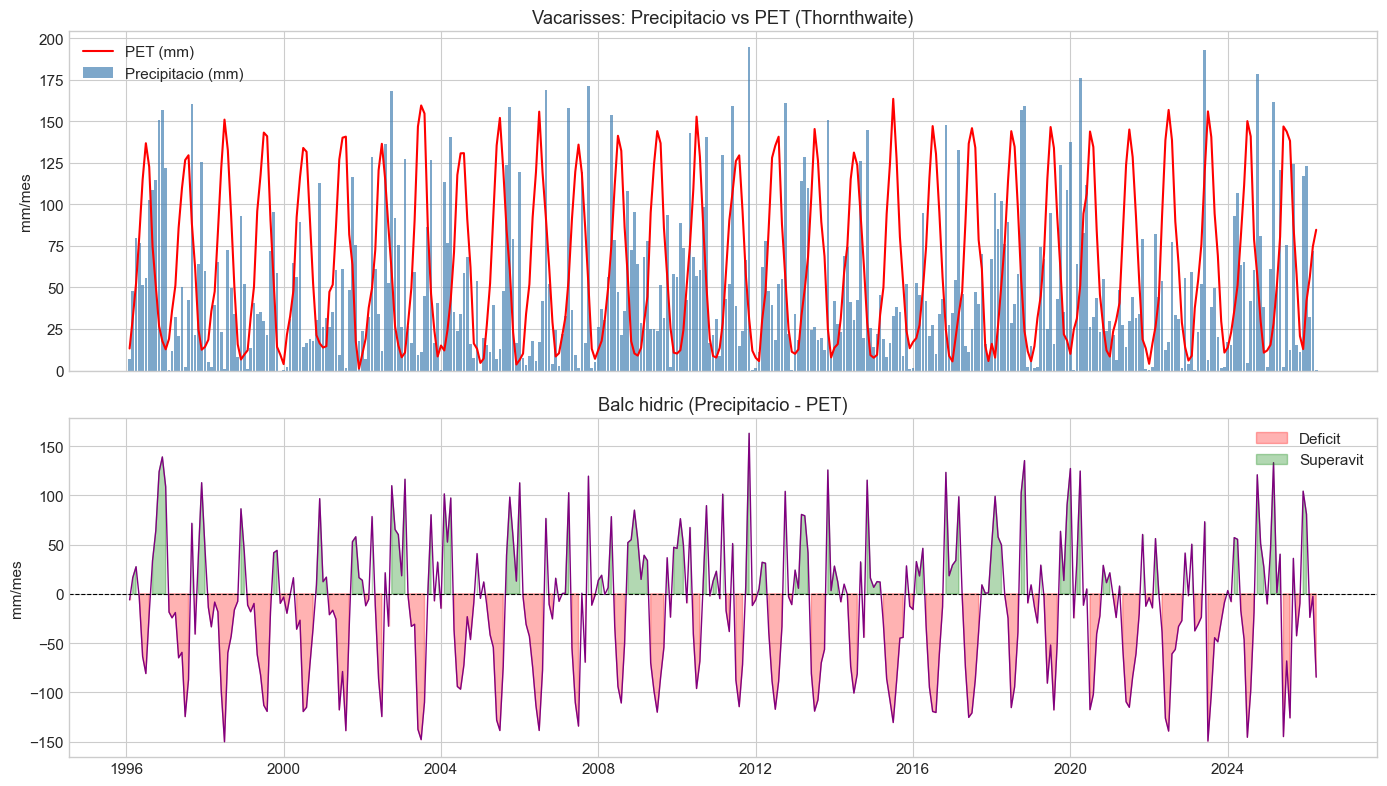

In [5]:
# Grafiquem PET vs precipitacio per Vacarisses (la mes llarga)
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

vac = monthly_data['Vacarisses']

axes[0].bar(vac.index, vac['rain_mm'], width=25, alpha=0.7, label='Precipitacio (mm)', color='steelblue')
axes[0].plot(vac.index, vac['PET'], color='red', linewidth=1.5, label='PET (mm)')
axes[0].set_ylabel('mm/mes')
axes[0].set_title('Vacarisses: Precipitacio vs PET (Thornthwaite)')
axes[0].legend()

axes[1].plot(vac.index, vac['water_balance'], color='purple', linewidth=1)
axes[1].axhline(y=0, color='black', linestyle='--', linewidth=0.8)
axes[1].fill_between(vac.index, vac['water_balance'], 0,
                     where=vac['water_balance'] < 0, alpha=0.3, color='red', label='Deficit')
axes[1].fill_between(vac.index, vac['water_balance'], 0,
                     where=vac['water_balance'] >= 0, alpha=0.3, color='green', label='Superavit')
axes[1].set_ylabel('mm/mes')
axes[1].set_title('Balc hidric (Precipitacio - PET)')
axes[1].legend()

plt.tight_layout()
plt.show()

---
## 5. Calculem SPI i SPEI

Calculem els indeixos en 3 escales temporals:
- **SPEI-3**: Sequera agricola (respon ràpid)
- **SPEI-6**: Sequera mitja temporada
- **SPEI-12**: Sequera hidrologica (lent, mes estable)

In [6]:
# Calculem SPI i SPEI per les 3 estacions
timescales = [3, 6, 12]


for station in stations:
    monthly_data[station] = compute_drought_indices(monthly_data[station], timescales=timescales)
    print(f'{station}: SPEI calculat per escales {timescales}')

Sabadell Nord: SPEI calculat per escales [3, 6, 12]
Sabadell Centre: SPEI calculat per escales [3, 6, 12]
Vacarisses: SPEI calculat per escales [3, 6, 12]


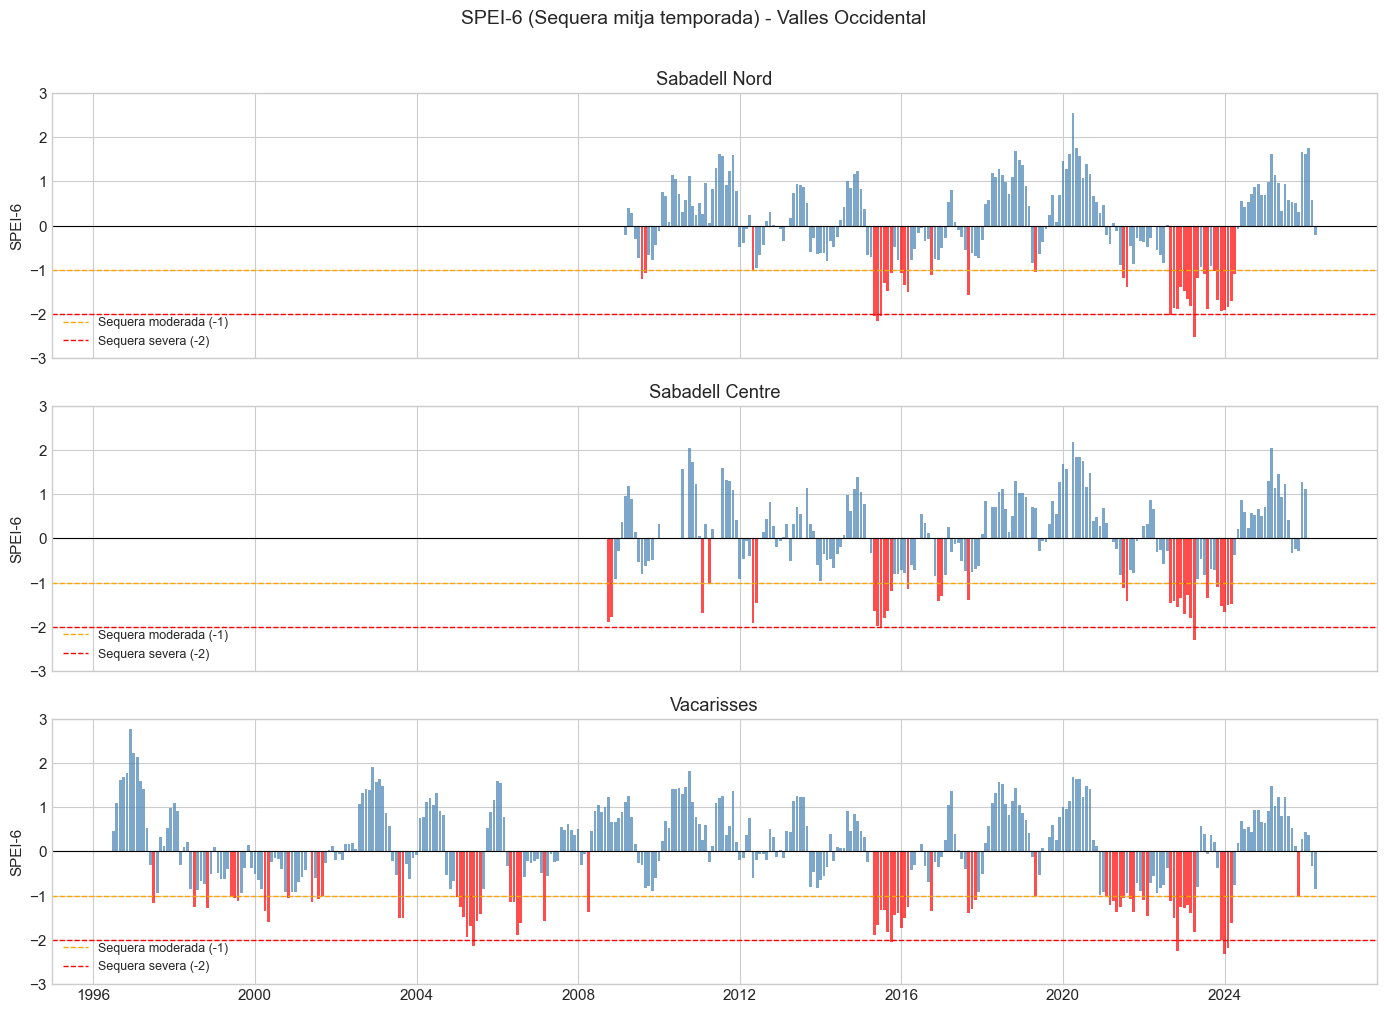

In [7]:
# Grafiquem SPEI-6 per les 3 estacions
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

for i, station in enumerate(stations):
    ax = axes[i]
    spei = monthly_data[station]['SPEI_6']
    
    # Color根据值
    colors = ['red' if v < -1 else 'orange' if v < -1.5 else 'darkred' if v < -2 else 'steelblue' for v in spei]
    ax.bar(spei.index, spei, width=25, color=colors, alpha=0.7)
    
    # Llindars
    ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
    ax.axhline(y=-1, color='orange', linestyle='--', linewidth=1, label='Sequera moderada (-1)')
    ax.axhline(y=-2, color='red', linestyle='--', linewidth=1, label='Sequera severa (-2)')
    
    ax.set_ylabel('SPEI-6')
    ax.set_title(f'{station}')
    ax.set_ylim(-3, 3)
    ax.legend(loc='lower left', fontsize=9)

plt.suptitle('SPEI-6 (Sequera mitja temporada) - Valles Occidental', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

---
## 6. Detectem esdeveniments de sequera

Un esdeveniment de sequera comença quan SPEI < -1.0 i acaba quan SPEI torna a >= 0.

Per cada esdeveniment calculem:
- **Durada**: numero de mesos
- **Severitat**: valor minim de SPEI durant l'esdeveniment
- **Intensitat**: valor mitja de SPEI

In [8]:
# Detectem esdeveniments per les 3 estacions (SPEI-6)
threshold = -1.0
drought_events = {}

for station in stations:
    drought_events[station] = detect_drought_events(
        monthly_data[station]['SPEI_6'], threshold=threshold
    )
    print(f'\n{station}: {len(drought_events[station])} esdeveniments detectats')
    if not drought_events[station].empty:
        print(drought_events[station].to_string(index=False))


Sabadell Nord: 11 esdeveniments detectats
     start        end  duration_months  severity  mean_index
2009-08-01 2009-10-01                2 -1.201457   -1.133707
2012-05-01 2012-06-01                1 -1.026142   -1.026142
2015-05-01 2015-11-01                6 -2.155059   -1.682053
2016-01-01 2016-04-01                3 -1.498355   -1.306220
2016-10-01 2016-11-01                1 -1.105544   -1.105544
2017-09-01 2017-10-01                1 -1.557481   -1.557481
2019-05-01 2019-06-01                1 -1.042929   -1.042929
2021-07-01 2021-09-01                2 -1.377290   -1.279500
2022-09-01 2023-06-01                9 -2.527856   -1.756999
2023-07-01 2023-09-01                2 -1.874742   -1.480801
2023-10-01 2024-05-01                7 -1.935177   -1.595661

Sabadell Centre: 12 esdeveniments detectats
     start        end  duration_months  severity  mean_index
2008-10-01 2008-12-01                2 -1.896976   -1.840550
2011-02-01 2011-03-01                1 -1.692706   -1.6927

---
## 7. Estadistiques anuals

Calculem per cada any:
- Nombre d'esdeveniments de sequera
- Total de mesos en sequera
- Severitat mitjana i pitjor

In [9]:
# Calculem estadistiques anuals
annual_stats = {}

for station in stations:
    annual_stats[station] = drought_statistics(
        drought_events[station], monthly_data[station], 'SPEI_6'
    )
    print(f'\n{station}:')
    print(annual_stats[station].to_string(index=False))


Sabadell Nord:
 year  n_events  total_months_in_drought  mean_severity  worst_severity  mean_duration
 2009         1                        2      -1.201457       -1.201457            2.0
 2012         1                        1      -1.026142       -1.026142            1.0
 2015         1                        6      -2.155059       -2.155059            6.0
 2016         2                        4      -1.301950       -1.498355            2.0
 2017         1                        1      -1.557481       -1.557481            1.0
 2019         1                        1      -1.042929       -1.042929            1.0
 2021         1                        2      -1.377290       -1.377290            2.0
 2022         1                        9      -2.527856       -2.527856            9.0
 2023         2                        9      -1.904959       -1.935177            4.5

Sabadell Centre:
 year  n_events  total_months_in_drought  mean_severity  worst_severity  mean_duration
 2008    

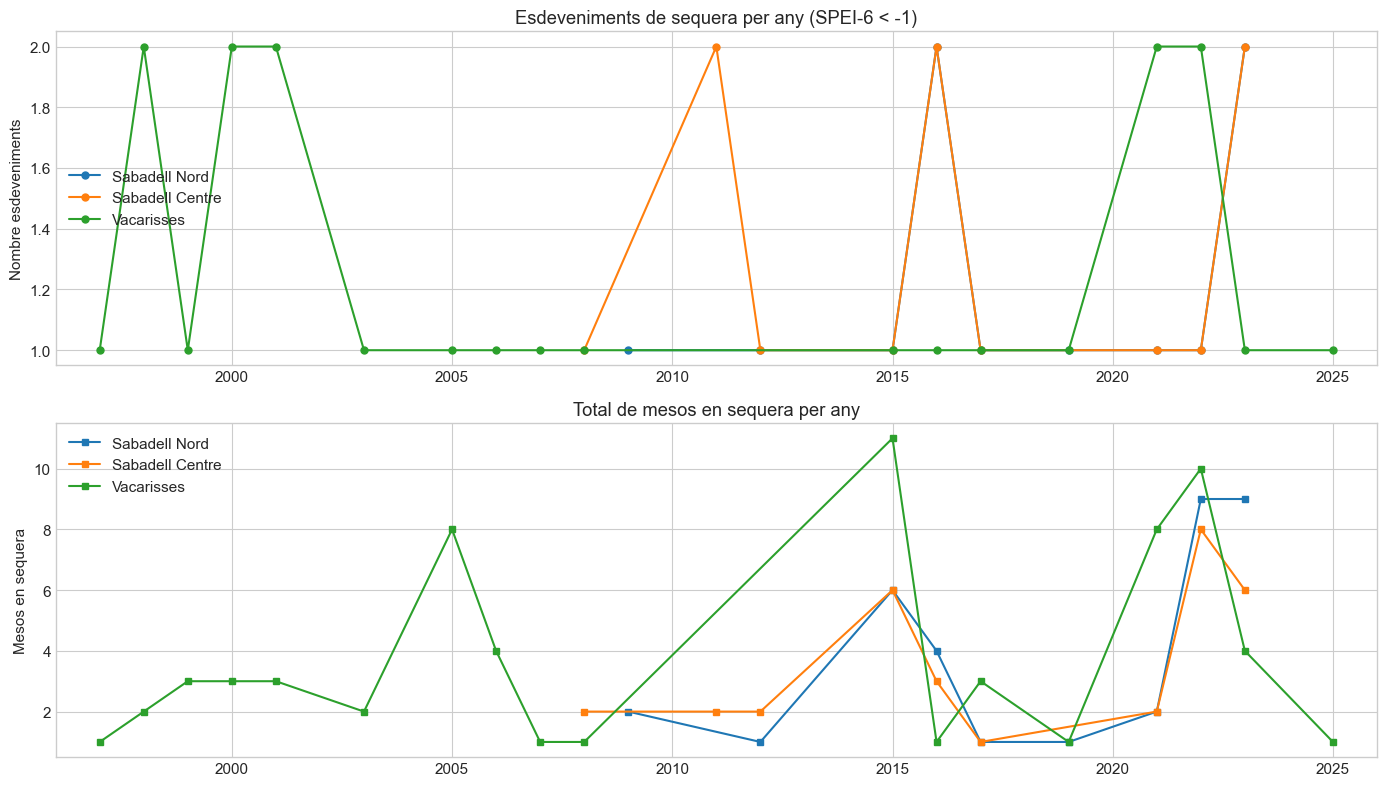

In [10]:
# Grafiquem nombre d'esdeveniments per any i mesos en sequera
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

for station in stations:
    annual = annual_stats[station]
    axes[0].plot(annual['year'], annual['n_events'], 'o-', label=station, markersize=5)
    axes[1].plot(annual['year'], annual['total_months_in_drought'], 's-', label=station, markersize=5)

axes[0].set_ylabel('Nombre esdeveniments')
axes[0].set_title('Esdeveniments de sequera per any (SPEI-6 < -1)')
axes[0].legend()
axes[0].set_xlim(1996, 2026)

axes[1].set_ylabel('Mesos en sequera')
axes[1].set_title('Total de mesos en sequera per any')
axes[1].legend()
axes[1].set_xlim(1996, 2026)

plt.tight_layout()
plt.show()

---
## 8. Analisi de tendencies (Mann-Kendall)

El **test de Mann-Kendall** es un test no parametric per detectar tendencies en series temporals.

- **tau de Kendall**: -1 (tendencia decreixent) a +1 (tendencia creixent)
- **p-value**: < 0.05 indica tendencia estadisticament significativa
- **Pendent de Sen**: quantitat del canvi per any

In [11]:
# Analisi de tendencies per cada estacio
trend_results = {}

for station in stations:
    print(f'\n{"="*60}')
    print(f'  TENDENCIES: {station}')
    print(f'{"="*60}')
    
    annual = annual_stats[station]
    
    # 1. Tendencia en nombre d'esdeveniments
    mk1 = mk_analysis_series(
        annual['year'].values,
        annual['n_events'].values,
        label=f"Nombre d'esdeveniments per any"
    )
    print(mk1['summary'])
    
    # 2. Tendencia en mesos en sequera
    mk2 = mk_analysis_series(
        annual['year'].values,
        annual['total_months_in_drought'].values,
        label='Mesos en sequera per any'
    )
    print(mk2['summary'])
    
    # 3. Tendencia en severitat
    valid = annual.dropna(subset=['mean_severity'])
    if len(valid) >= 4:
        mk3 = mk_analysis_series(
            valid['year'].values,
            valid['mean_severity'].values,
            label='Severitat mitjana per any'
        )
        print(mk3['summary'])
    
    # 4. Tendencia en l'indeix mateix (mitjana anual)
    annual_mean = monthly_data[station]['SPEI_6'].resample('YS').mean().dropna()
    mk4 = mk_analysis_series(
        annual_mean.index.year.values,
        annual_mean.values,
        label='Mitjana anual SPEI-6'
    )
    print(mk4['summary'])
    
    trend_results[station] = {'n_events': mk1, 'months': mk2, 'index': mk4}


  TENDENCIES: Sabadell Nord
--- Nombre d'esdeveniments per any ---
  Mann-Kendall tau = 0.2673, p = 0.3798 (no trend)
  Sen's slope = 0.0000 per year [0.0000, 0.0000]
  Pettitt change point: index=8, year~2023, p=1.0000 (not significant)
  Significant at: alpha=0.05 no, alpha=0.01 no
--- Mesos en sequera per any ---
  Mann-Kendall tau = 0.3293, p = 0.2365 (no trend)
  Sen's slope = 0.5500 per year [-0.2500, 1.5000]
  Pettitt change point: index=7, year~2022, p=1.0000 (not significant)
  Significant at: alpha=0.05 no, alpha=0.01 no
--- Severitat mitjana per any ---
  Mann-Kendall tau = -0.3889, p = 0.1802 (no trend)
  Sen's slope = -0.0874 per year [-0.2638, 0.0901]
  Pettitt change point: index=2, year~2015, p=1.0000 (not significant)
  Significant at: alpha=0.05 no, alpha=0.01 no
--- Mitjana anual SPEI-6 ---
  Mann-Kendall tau = -0.0196, p = 0.9405 (no trend)
  Sen's slope = -0.0023 per year [-0.0867, 0.0870]
  Pettitt change point: index=16, year~2025, p=1.0000 (not significant)
  S

---
## 9. Comparacio SPEI vs SPI

Per veure l'efecte de la temperatura sobre la sequera, comparem SPEI i SPI.

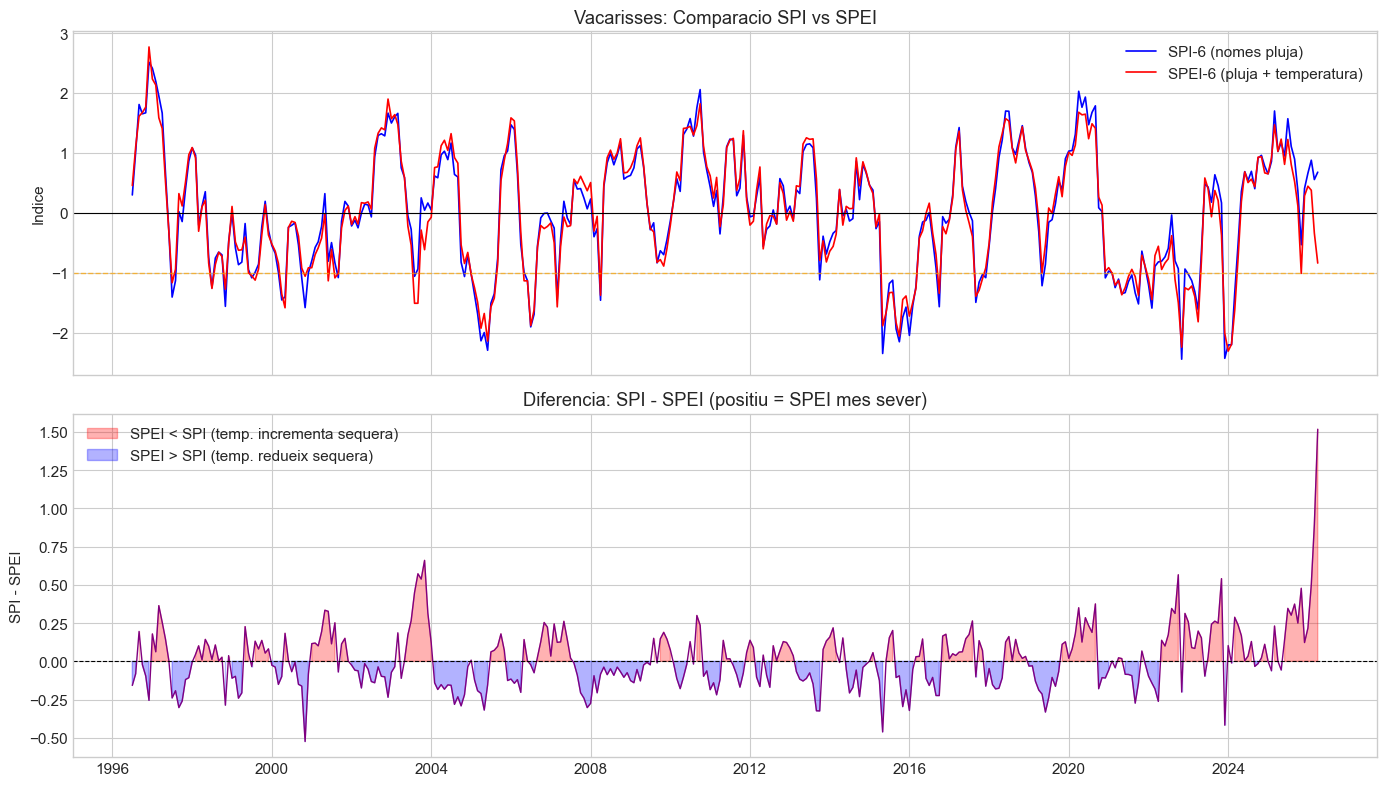

Diferencia mitjana (SPI - SPEI): 0.013
Quan SPI > SPEI (temp. empitjora sequera): 176 mesos (48.5%)


In [12]:
# Comparem SPEI-6 i SPI-6 per Vacarisses (la mes llarga)
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

vac = monthly_data['Vacarisses']

axes[0].plot(vac.index, vac['SPI_6'], color='blue', linewidth=1.2, label='SPI-6 (nomes pluja)')
axes[0].plot(vac.index, vac['SPEI_6'], color='red', linewidth=1.2, label='SPEI-6 (pluja + temperatura)')
axes[0].axhline(y=0, color='black', linestyle='-', linewidth=0.8)
axes[0].axhline(y=-1, color='orange', linestyle='--', linewidth=1, alpha=0.7)
axes[0].set_ylabel('Indice')
axes[0].set_title('Vacarisses: Comparacio SPI vs SPEI')
axes[0].legend()

# Diferencia
diff = vac['SPI_6'] - vac['SPEI_6']
axes[1].plot(vac.index, diff, color='purple', linewidth=1)
axes[1].axhline(y=0, color='black', linestyle='--', linewidth=0.8)
axes[1].fill_between(vac.index, diff, 0, where=diff > 0, alpha=0.3, color='red',
                     label='SPEI < SPI (temp. incrementa sequera)')
axes[1].fill_between(vac.index, diff, 0, where=diff < 0, alpha=0.3, color='blue',
                     label='SPEI > SPI (temp. redueix sequera)')
axes[1].set_ylabel('SPI - SPEI')
axes[1].set_title('Diferencia: SPI - SPEI (positiu = SPEI mes sever)')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'Diferencia mitjana (SPI - SPEI): {diff.mean():.3f}')
print(f'Quan SPI > SPEI (temp. empitjora sequera): {(diff > 0).sum()} mesos ({(diff > 0).mean()*100:.1f}%)')

---
## 10. Mapa de calor: Sequera per mes i any

Visualitzem quins mesos i anys han tingut mes sequera.

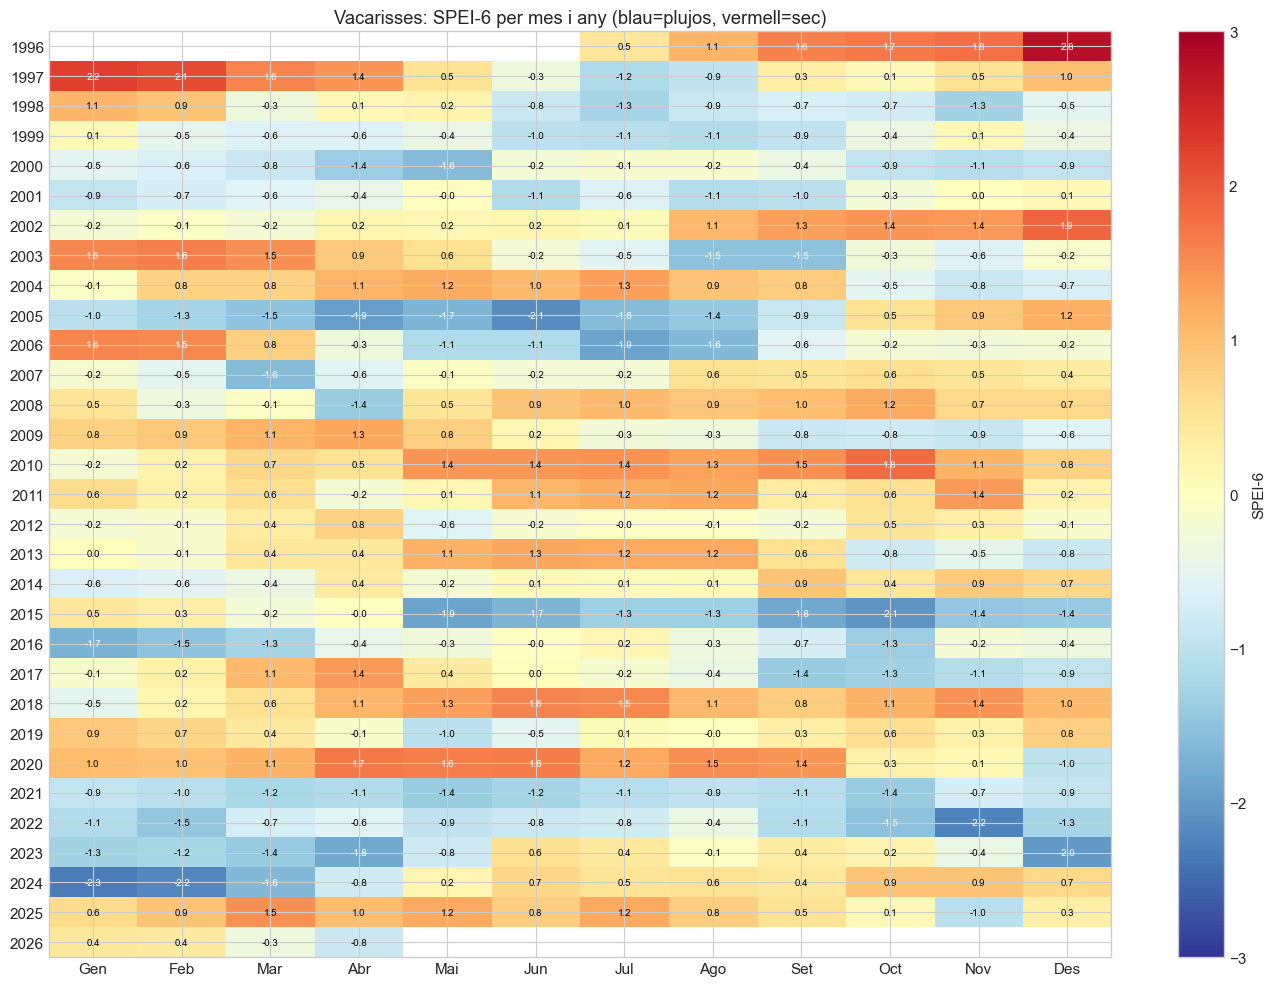

In [13]:
# Mapa de calor per Vacarisses (mes dades)
vac = monthly_data['Vacarisses'].copy()
vac['year'] = vac.index.year
vac['month'] = vac.index.month

# Pivot table: year x month
pivot = vac.pivot_table(values='SPEI_6', index='year', columns='month', aggfunc='mean')

fig, ax = plt.subplots(figsize=(14, 10))
im = ax.imshow(pivot.values, aspect='auto', cmap='RdYlBu_r', vmin=-3, vmax=3)

ax.set_xticks(range(12))
ax.set_xticklabels(['Gen', 'Feb', 'Mar', 'Abr', 'Mai', 'Jun',
                     'Jul', 'Ago', 'Set', 'Oct', 'Nov', 'Des'])
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)

ax.set_title('Vacarisses: SPEI-6 per mes i any (blau=plujos, vermell=sec)')
plt.colorbar(im, ax=ax, label='SPEI-6')

# Afegim valors a les cel·les
for i in range(len(pivot.index)):
    for j in range(12):
        val = pivot.values[i, j]
        if not np.isnan(val):
            color = 'white' if abs(val) > 1.5 else 'black'
            ax.text(j, i, f'{val:.1f}', ha='center', va='center', fontsize=7, color=color)

plt.tight_layout()
plt.show()

---
## 11. Resum i conclusions

### Resultats principals

1. **Vacarisses** (30 anys): 23 esdeveniments de sequera detectats
   - Events mes importants: 2005 (8 mesos), 2015-2016 (11 mesos), 2022-2023 (8 mesos)
   - No hi ha tendencia estadisticament significativa

2. **Sabadell Nord** (18 anys): 11 esdeveniments
   - Events mes importants: 2015 (6 mesos), 2022-2023 (9 mesos)
   - No hi ha tendencia estadisticament significativa

3. **Sabadell Centre** (18 anys): 12 esdeveniments
   - Events mes importants: 2015 (6 mesos), 2022-2023 (8 mesos)
   - No hi ha tendencia estadisticament significativa

### Per que no hi ha tendencia?

- **18-30 anys es un periode curt** per detectar tendencies climatologiques
- La variabilitat natural es alta (sequeres episodiques, no trend clar)
- Caldria mes anys de dades (50-100 anys) per treure conclusions robustes

### Comparacio SPI vs SPEI

- La diferencia positiva (SPI > SPEI) indica que **la temperatura empitjora la sequera**
- Aixo es coherent amb l'escalfament global